In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

from scipy.signal import savgol_filter
from nanonets.utils.plotting import BLUE_COLOR, RED_COLOR

plt.style.use(["science","bright","grid"])

In [36]:
T_WRITE_LIST    = [0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2]
T_WAIT_LIST     = [0.0,0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2,102.4]
PATH            = "../../data/raw/dynamic_resistances/paired_pulse/"
data = {}

for t_write in T_WRITE_LIST:
    data[t_write] = {}
    for t_wait in T_WAIT_LIST:
        df  = pd.read_csv(f"{PATH}Nx=9_Ny=9_Ne=2_tw{t_write:.1f}ns_twait{t_wait:.1f}ns.csv")
        df  = df.drop(columns=['E1','G','Eq_Jumps','Jumps'])
        
        df['Total'] = df['Observable'] + df['Displacement']
        df['Resistance'] = pd.read_parquet(f"{PATH}resistances_Nx=9_Ny=9_Ne=2_tw{t_write:.1f}ns_twait{t_wait:.1f}ns.parquet").mean(axis=1).values
        df['Potential'] = pd.read_parquet(f"{PATH}mean_state_Nx=9_Ny=9_Ne=2_tw{t_write:.1f}ns_twait{t_wait:.1f}ns.parquet").mean(axis=1).values
        
        data[t_write][t_wait] = df

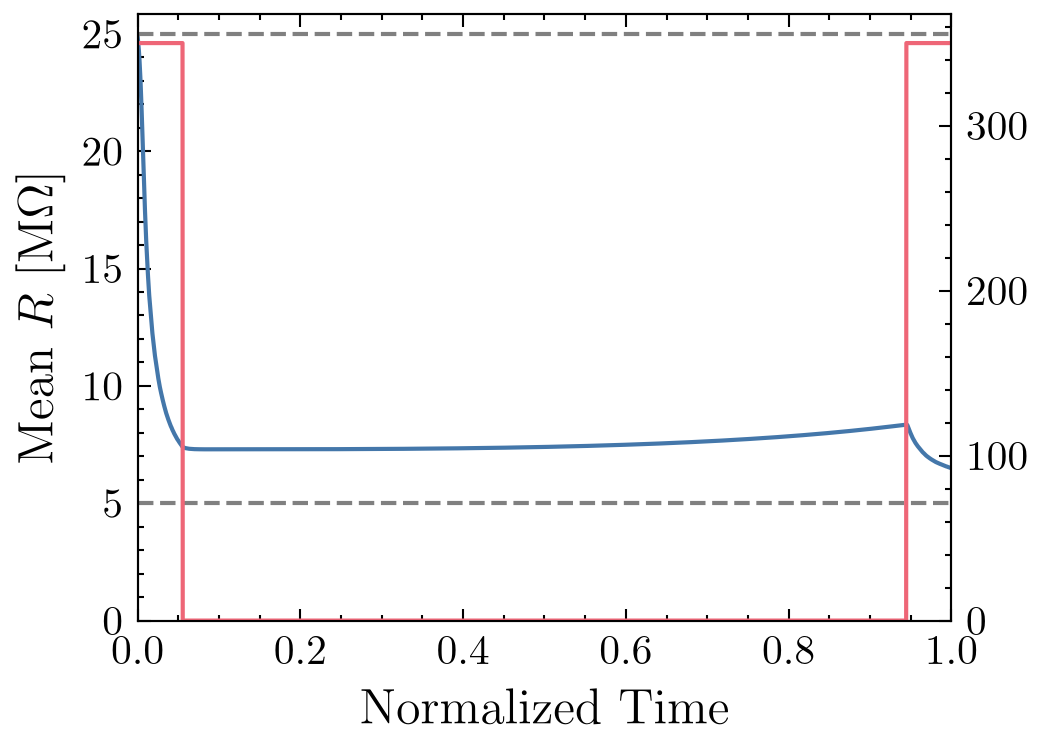

In [45]:
t_write = 3.2
t_wait = 51.2
t_plot = data[t_write][t_wait]['t'].values*1e9
r_plot = data[t_write][t_wait]['Resistance'].values
u_plot = data[t_write][t_wait]['E0'].values*1000

fig, ax = plt.subplots(dpi=300)
_ = ax.plot(t_plot/t_plot.max(), r_plot, color=BLUE_COLOR)
_ = ax.set_ylim(0)
_ = ax.axhline(5, color='grey', ls='--')
_ = ax.axhline(25, color='grey', ls='--')
_ = ax.set_ylabel(r"Mean $R$ [M$\Omega$]", size="large")
_ = ax.set_xlabel(r"Normalized Time", size="large")
_ = ax.grid(False)
_ = ax.set_xlim(0,1)


ax2 = ax.twinx()
_ = ax2.plot(t_plot/t_plot.max(), u_plot, color=RED_COLOR)
_ = ax2.set_ylim(0)
_ = ax2.set_xlim(0,1)
_ = ax2.grid(False)

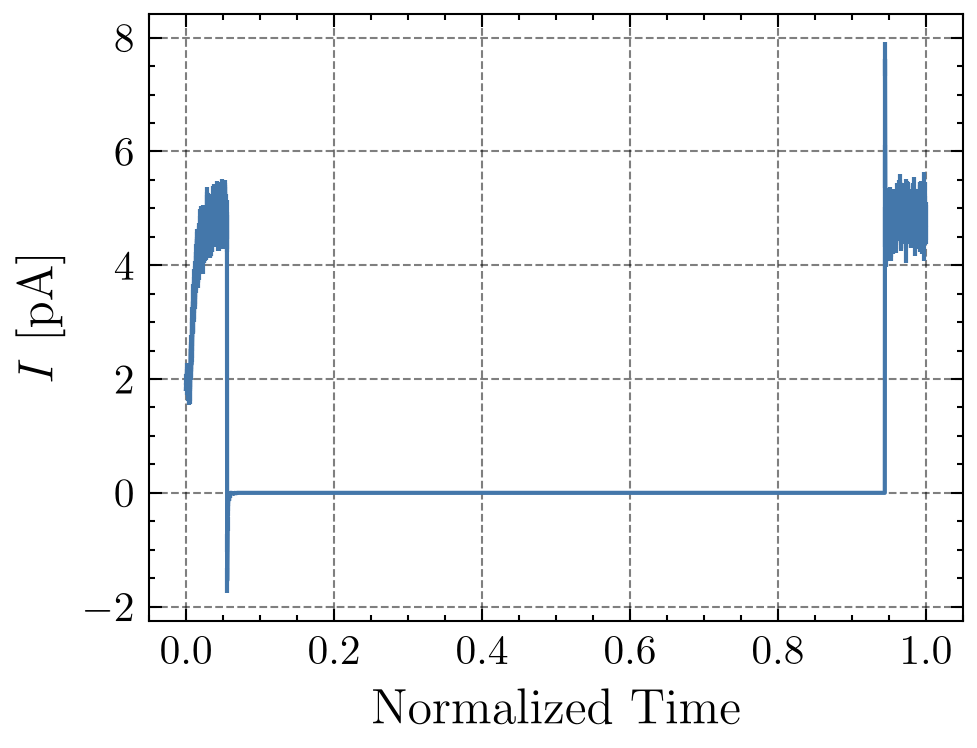

In [46]:
t_plot = data[t_write][t_wait]['t'].values*1e9
y_plot = data[t_write][t_wait]['Observable'].values*1e-9
e_plot = data[t_write][t_wait]['Error'].values*1e-9

fig, ax = plt.subplots(dpi=300)
_ = ax.errorbar(t_plot/t_plot.max(), y_plot, e_plot)
# _ = ax.set_ylim(0)
_ = ax.set_ylabel(r"$I$ [pA]", size="large")
_ = ax.set_xlabel(r"Normalized Time", size="large")